## Creating a Waffle Chart Using CRISPR Crops Patent Application and Grant Data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('patent_data_abbreviated.csv')

In [3]:
df.head()

,Application Id,Application Number,Office,Application Date_page,Grant Number,Grant Date,Applicants,Title_page,Priority Data,Related Patent Documents,...,applicant_city_name,applicant_state_name,applicant_country_name,crop,Days Between Application and Grant,Granted,Application Year,Grant Year,Has Related Patent Documents,purpose
0,CN324347467,201911093561.X,China,2019-11-11,112779265.0,2022-11-08,Institute Of Genetics And Developmental Biolog...,(EN) Breeding method for carrying out saturate...,NaN,NaN,...,Shi Jia Zhuang Shi,He Bei Sheng,China,Crop plants,1093.0,True,2019.0,2022.0,False,Other Genetic Improvement for Crop Traits
1,CN417838467,202311185645,China,2023-09-13,NaN,NaN,Shengyan Private Life Technology (Shanghai) Co...,(EN) Method for improving plant gene editing e...,NaN,NaN,...,NaN,Shang Hai Shi,China,Crop plants,NaN,False,2023.0,NaN,False,Gene Editing Systems Development
2,CA382074342,3183409,Canada,2021-05-28,NaN,NaN,"Pioneer Hi-Bred International, Inc.",(EN) LARGE SCALE GENOME MANIPULATION(FR) MANIP...,"63/031,822 29.05.2020 US",WO/2021/243115\n\nCN115698302\n\nEP4158033\n\n...,...,New Holland,Pennsylvania,United States,Crop plants,NaN,False,2021.0,NaN,True,Other Genetic Improvement for Crop Traits
3,CN391941406,202180038896,China,2021-05-28,NaN,NaN,"Pioneer Hi-Bred International, Inc.",(EN) Large scale genome manipulation(ZH) 大规模基因组操纵,63/031822 29.05.2020 US,WO/2021/243115\n\nCA3183409\n\nEP4158033\n\nUS...,...,New Holland,Pennsylvania,United States,Crop plants,NaN,False,2021.0,NaN,True,Other Genetic Improvement for Crop Traits
4,WO2021243115,PCT/US2021/034704,NaN,NaN,NaN,NaN,"Pioneer Hi-Bred International, Inc.",(EN) LARGE SCALE GENOME MANIPULATION(FR) MANIP...,"63/031,82229.05.2020US",CA3183409\n\nCN115698302\n\nEP4158033\n\nUS202...,...,Elizabethtown,Pennsylvania,United States,Crop plants,NaN,False,NaN,NaN,True,Other Genetic Improvement for Crop Traits


In [32]:
df.shape

(1468, 26)

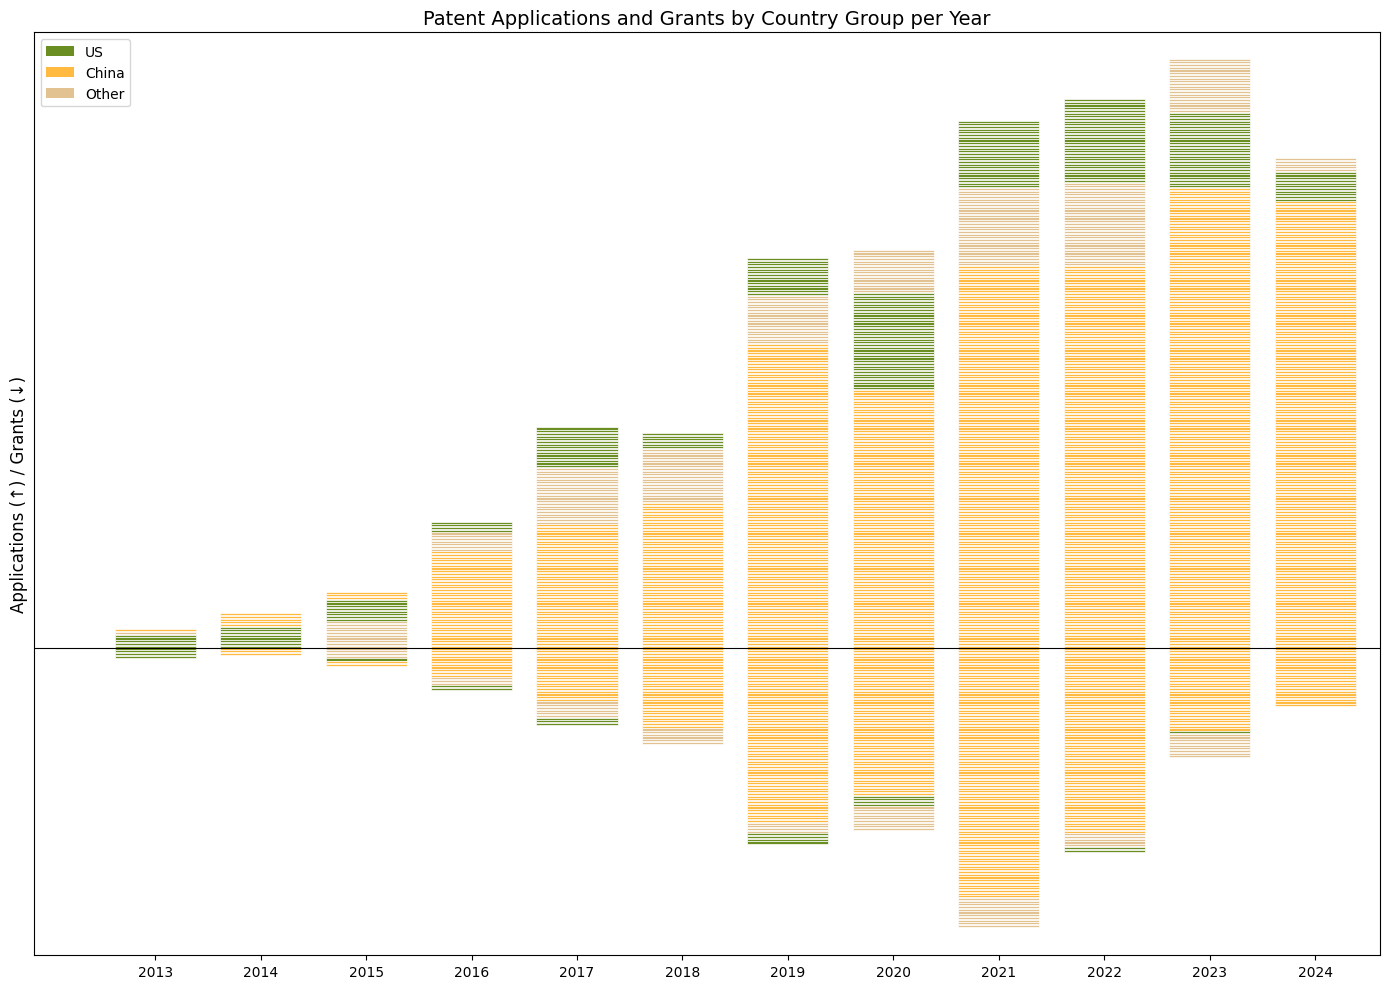

In [73]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Grouping function
def group_country(name):
    if name == 'China':
        return 'China'
    elif name == 'United States':
        return 'US'
    else:
        return 'Other'

# Prepare the data
apps = df[~df['Application Year'].isna()].copy()
apps['Application Year'] = apps['Application Year'].astype(int)
apps['CountryGroup'] = apps['applicant_country_name'].apply(group_country)

apps['Year'] = apps['Application Year']
years = sorted(apps['Year'].dropna().unique())

# Box layout settings
box_width = 1
box_height = 5.5
vertical_step = 7
spacing = 1.3

# Color palette
country_colors = {
    'US': '#6B8E23',
    'China': '#ffba3f',
    'Other': '#E2C290'
}

# Create figure with explicit white background for Illustrator compatibility
fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')
ax.set_facecolor('white')

# Main plotting loop
for i, year in enumerate(years):
    x_offset = i * spacing
    year_data = apps[apps['Year'] == year].copy()

    # Sort stacking order by frequency
    country_order = year_data['CountryGroup'].value_counts().index.tolist()
    year_data['CountryGroup'] = pd.Categorical(year_data['CountryGroup'], categories=country_order, ordered=True)
    year_data = year_data.sort_values('CountryGroup')

    # Upward: Applications
    y_pos = 0
    for _, row in year_data.iterrows():
        ax.add_patch(
            mpatches.Rectangle(
                (x_offset, y_pos), box_width, box_height,
                facecolor=country_colors.get(row['CountryGroup'], '#cccccc'),
                edgecolor='white', linewidth=0.5
            )
        )
        y_pos += vertical_step

    # Downward: Grants
    granted_rows = year_data[year_data['Granted'] == True]
    y_neg = -box_height
    for _, row in granted_rows.iterrows():
        ax.add_patch(
            mpatches.Rectangle(
                (x_offset, y_neg), box_width, box_height,
                facecolor=country_colors.get(row['CountryGroup'], '#cccccc'),
                edgecolor='white', linewidth=0.5
            )
        )
        y_neg -= vertical_step

# Axis styling
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlim(-1, len(years) * spacing)
ax.set_ylim(-800, 1600)
ax.set_xticks([i * spacing + box_width/2 for i in range(len(years))])
ax.set_xticklabels([str(int(y)) for y in years], fontsize=10)
ax.set_yticks([])
ax.set_ylabel('Applications (↑) / Grants (↓)', fontsize=12)
ax.set_title('Patent Applications and Grants by Country Group per Year', fontsize=14)

# Legend
handles = [
    mpatches.Patch(facecolor=color, label=label)
    for label, color in country_colors.items()
]
ax.legend(handles=handles, loc='upper left', fontsize=10)

plt.tight_layout()

# Save as SVG with tight bounding box and white background for Illustrator
plt.savefig('patent_applications_and_grants.svg', format='svg', bbox_inches='tight', facecolor='white')
plt.show()

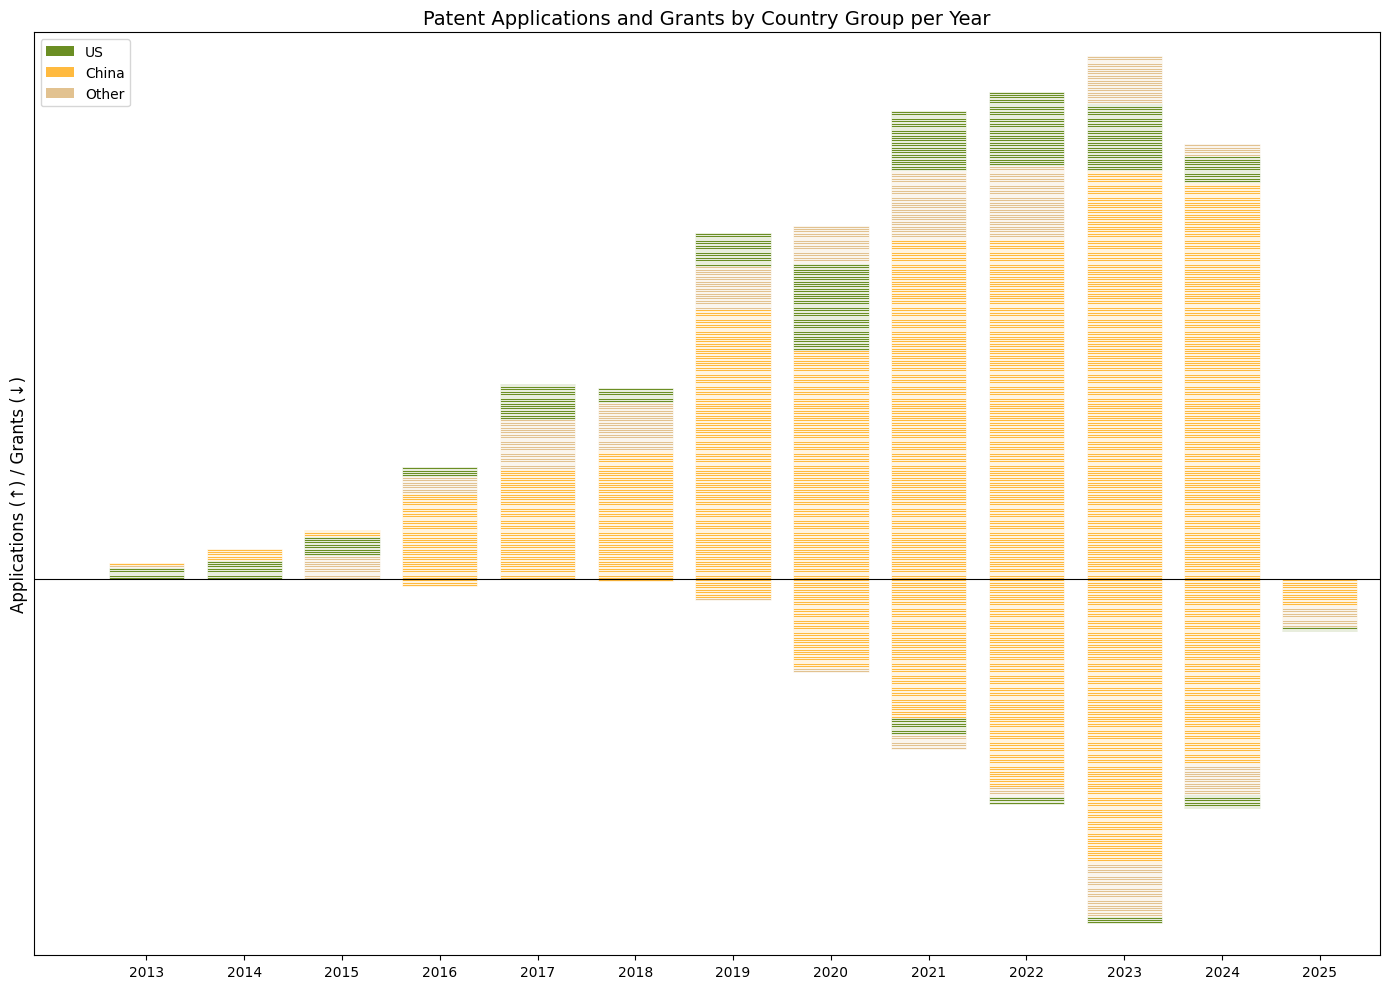

In [78]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Grouping function
def group_country(name):
    if name == 'China':
        return 'China'
    elif name == 'United States':
        return 'US'
    else:
        return 'Other'

# Prepare the data
apps = df[~df['Application Year'].isna()].copy()
apps['Application Year'] = apps['Application Year'].astype(int)
apps['CountryGroup'] = apps['applicant_country_name'].apply(group_country)

apps['Year'] = apps['Application Year']
apps['Grant Year'] = pd.to_numeric(apps['Grant Year'], errors='coerce')
years = sorted(pd.concat([
    apps['Application Year'],
    apps.loc[apps['Granted'] == True, 'Grant Year']
]).dropna().astype(int).unique())

# Box layout settings
box_width = 1
box_height = 5.5
vertical_step = 7
spacing = 1.3

# Color palette
country_colors = {
    'US': '#6B8E23',
    'China': '#ffba3f',
    'Other': '#E2C290'
}

# Create figure with explicit white background for Illustrator compatibility
fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')
ax.set_facecolor('white')

# Plot Applications (based on Application Year)
for i, year in enumerate(years):
    x_offset = i * spacing
    year_data = apps[apps['Application Year'] == year].copy()

    # Sort stacking order by frequency
    country_order = year_data['CountryGroup'].value_counts().index.tolist()
    year_data['CountryGroup'] = pd.Categorical(year_data['CountryGroup'], categories=country_order, ordered=True)
    year_data = year_data.sort_values('CountryGroup')

    # Upward: Applications
    y_pos = 0
    for _, row in year_data.iterrows():
        ax.add_patch(
            mpatches.Rectangle(
                (x_offset, y_pos), box_width, box_height,
                facecolor=country_colors.get(row['CountryGroup'], '#cccccc'),
                edgecolor='white', linewidth=0.5
            )
        )
        y_pos += vertical_step

# Plot Grants (based on Grant Year)
for i, year in enumerate(years):
    x_offset = i * spacing
    grant_data = apps[(apps['Granted'] == True) & (apps['Grant Year'] == year)].copy()

    # Sort stacking order by frequency
    country_order = grant_data['CountryGroup'].value_counts().index.tolist()
    grant_data['CountryGroup'] = pd.Categorical(grant_data['CountryGroup'], categories=country_order, ordered=True)
    grant_data = grant_data.sort_values('CountryGroup')

    # Downward: Grants
    y_neg = -box_height
    for _, row in grant_data.iterrows():
        ax.add_patch(
            mpatches.Rectangle(
                (x_offset, y_neg), box_width, box_height,
                facecolor=country_colors.get(row['CountryGroup'], '#cccccc'),
                edgecolor='white', linewidth=0.5
            )
        )
        y_neg -= vertical_step

# Axis styling
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlim(-1, len(years) * spacing)
ax.set_ylim(-1100, 1600)
ax.set_xticks([i * spacing + box_width / 2 for i in range(len(years))])
ax.set_xticklabels([str(int(y)) for y in years], fontsize=10)
ax.set_yticks([])
ax.set_ylabel('Applications (↑) / Grants (↓)', fontsize=12)
ax.set_title('Patent Applications and Grants by Country Group per Year', fontsize=14)

# Legend
handles = [
    mpatches.Patch(facecolor=color, label=label)
    for label, color in country_colors.items()
]
ax.legend(handles=handles, loc='upper left', fontsize=10)

plt.tight_layout()

# Save as SVG with tight bounding box and white background for Illustrator
plt.savefig('patent_applications_and_grants.svg', format='svg', bbox_inches='tight', facecolor='white')
plt.show()